In [2]:
import sys
print(sys.executable)

/opt/anaconda3/envs/ml_env/bin/python


In [4]:
## Interpretation ofn the linear SVR moded

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.model_selection import RepeatedKFold, KFold, RandomizedSearchCV, cross_validate, cross_val_score, cross_val_predict
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap

/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

DATA_DIR   = PROJECT_DIR / "data" / "processed"
FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True) 

DATA_PATH = DATA_DIR / "shortprotocol_firstconsentedcycle.csv"

print("Project dir:", PROJECT_DIR.resolve())
assert DATA_PATH.exists(), f"CSV not found at {DATA_PATH} — check PROJECT_DIR depth"

Project dir: /Users/kristinastoianova/Desktop/ivf_ml_research


In [7]:
df = pd.read_csv(DATA_PATH) 
df.head()

,Unique_number,Aetiology,Aetiology_group,Egg_donor,PGD,Male_factor,Funding,Infertility_duration,Treatment,Age,...,Semen_vol,Sperm_prep,Sperm_mobility,No_eggs,No_mature_eggs,No_fertilised,Fertilisation_rate,Proportion_mature,Egg_donor_flag,Aetiology_clean
0,6994870M,Tubal Factors,Female_factor,0,N,N,PP,12.0,IVF,34.7,...,3.1,DG,N,8,8,1.0,0.125000,100.000000,0,tubal factors
1,6756242R,No Female Factor,No_female_factor,0,Y,Y,NHS,81.0,PGD,30.0,...,3.0,DG,N,7,7,4.0,0.571429,100.000000,0,no female factor
2,8009564A,PCO,Female_factor,0,N,Y,NHS,54.0,ICSI,35.1,...,1.9,DG,N,9,8,5.0,0.625000,88.888889,0,pco
3,6927140N,Endometriosis,Female_factor,0,N,N,PP,77.0,IVF,33.6,...,2.2,DG,N,14,13,4.0,0.307692,92.857143,0,endometriosis
4,6567290A,Unexplained,Unexplained,0,N,N,NHS,30.0,ICSI,39.7,...,3.0,DG,N,19,10,5.0,0.500000,52.631579,0,unexplained


In [8]:
df['Baseline_AMH_log'] = np.log1p(df['Baseline_AMH'])
df['Baseline_follicles_log'] = np.log1p(df['Baseline_total_follicles'])

TARGET = "No_mature_eggs"
LOG_TRANSFORM = True

AETIOLOGY_CATEGORIES = [
    "Female_factor",
    "No_female_factor",
    "Unexplained",
]

# Hyperparameters from the screening shortlist
SVR_C = 1.50271372141546
SVR_EPSILON = 0.422587464499617
SVR_KERNEL = "linear"
SVR_GAMMA = "scale"

# Put in selected predictor set
NUMERIC_FEATURES = [
    "Baseline_AMH_log",
    "Baseline_follicles_log",
    "BMI"
]

CATEGORICAL_FEATURES = [
    "Aetiology_group"
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

df["Aetiology_group"] = pd.Categorical(
    df["Aetiology_group"],
    categories=AETIOLOGY_CATEGORIES
)

X = df[ALL_FEATURES].copy()

y_raw = df[TARGET].copy()
y = np.log1p(y_raw) if LOG_TRANSFORM else y_raw

In [9]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(
        n_neighbors=5,
        weights="distance",
        metric="nan_euclidean"
    ))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        categories=[AETIOLOGY_CATEGORIES],
        drop="first",
        sparse_output=False,
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(C=SVR_C, epsilon=SVR_EPSILON,
                  kernel=SVR_KERNEL, gamma=SVR_GAMMA)),
])

In [10]:
kf_predict = KFold(n_splits=5, shuffle=True, random_state=7)

y_pred_cv = cross_val_predict(pipeline, X, y, cv=kf_predict)

if LOG_TRANSFORM:
    y_eval      = np.expm1(y).to_numpy()
    y_pred_eval = np.expm1(y_pred_cv)
else:
    y_eval      = y.to_numpy()
    y_pred_eval = y_pred_cv

oof_mae  = mean_absolute_error(y_eval, y_pred_eval)
oof_rmse = np.sqrt(mean_squared_error(y_eval, y_pred_eval))
oof_r2   = r2_score(y_eval, y_pred_eval)       # 1 - SS_res/SS_tot

print(f"OOF MAE  = {oof_mae:.3f} MII oocytes")
print(f"OOF RMSE = {oof_rmse:.3f} MII oocytes")
print(f"OOF R2   = {oof_r2:.3f}")

OOF MAE  = 3.976 MII oocytes
OOF RMSE = 5.528 MII oocytes
OOF R2   = 0.543


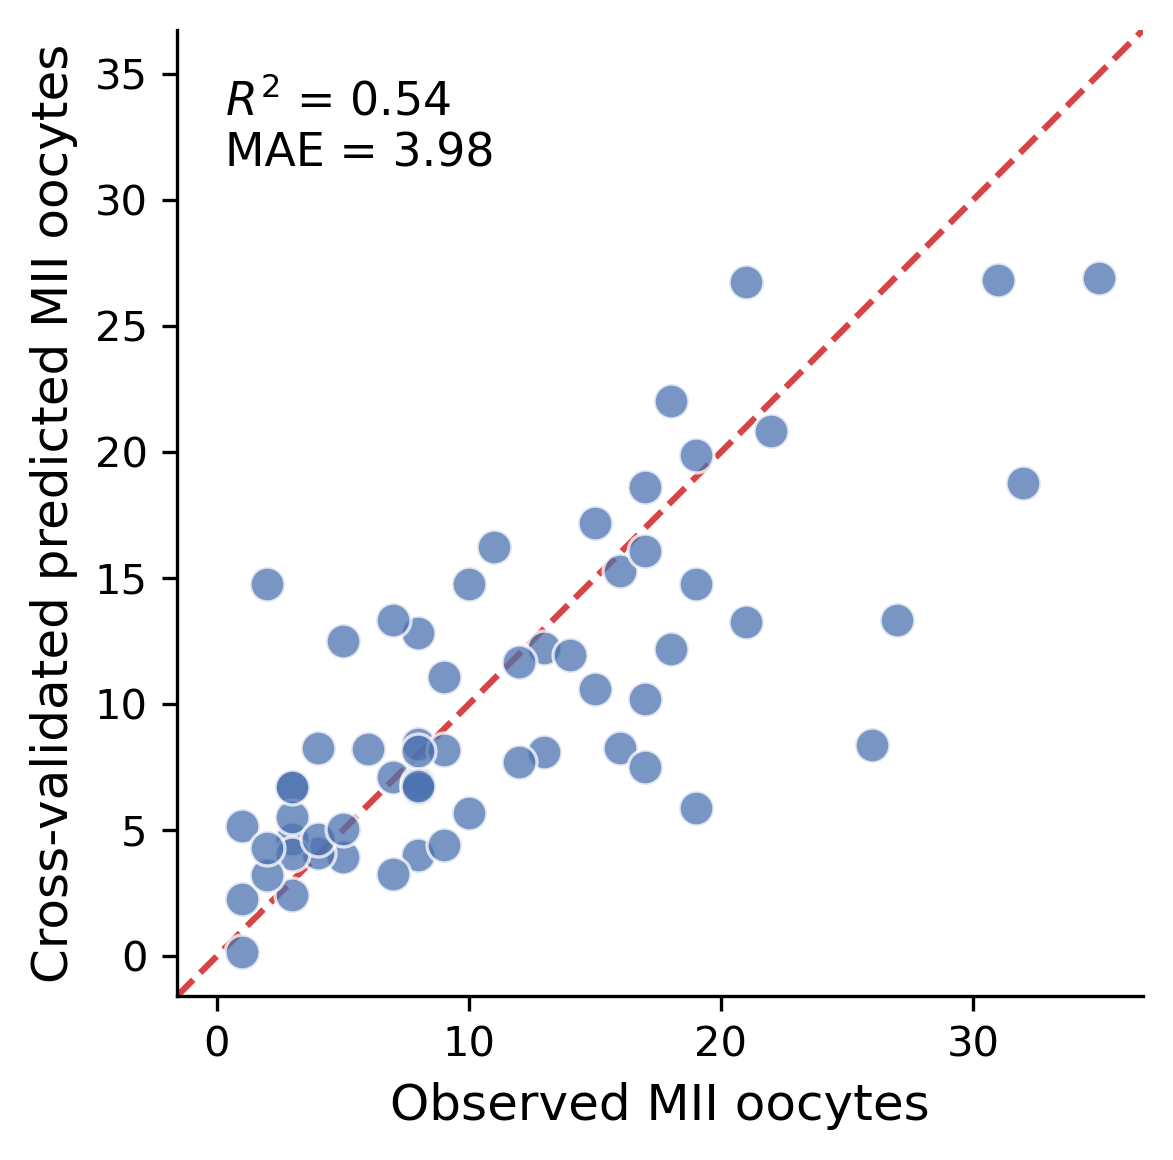

In [18]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=300)

min_val = min(y_eval.min(), y_pred_eval.min())
max_val = max(y_eval.max(), y_pred_eval.max())
pad  = (max_val - min_val) * 0.05
lims = [min_val - pad, max_val + pad]

ax.plot(lims, lims, linestyle="--", color="#D64545", linewidth=1.5, zorder=1)
ax.scatter(y_eval, y_pred_eval, s=70, color="#4C72B0", alpha=0.75,
           edgecolor="white", linewidth=0.8, zorder=2)

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Observed MII oocytes", fontsize=12)
ax.set_ylabel("Cross-validated predicted MII oocytes", fontsize=12)

ax.text(0.05, 0.95, f"$R^2$ = {oof_r2:.2f}\nMAE = {oof_mae:.2f}",
        transform=ax.transAxes, fontsize=11, va="top")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/svr_predicted_vs_observed.png", dpi=300, bbox_inches="tight")
plt.show()

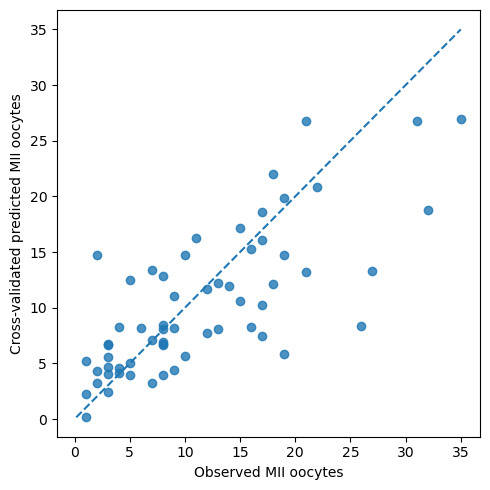

In [17]:
plt.figure(figsize=(5, 5))

plt.scatter(y_eval, y_pred_eval, alpha=0.8)

min_val = min(y_eval.min(), y_pred_eval.min())
max_val = max(y_eval.max(), y_pred_eval.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed MII oocytes")
plt.ylabel("Cross-validated predicted MII oocytes")
#plt.title("Predicted vs observed MII oocytes")

plt.tight_layout()
plt.savefig("../figures/predicted_observed.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
from sklearn.base import clone

perm_folds = []
for train_idx, test_idx in kf_predict.split(X):
    fold_pipe = clone(pipeline)
    fold_pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
    r = permutation_importance(
        fold_pipe,
        X.iloc[test_idx], y.iloc[test_idx],
        n_repeats=100,
        random_state=42,
        scoring="neg_mean_absolute_error",
    )
    perm_folds.append(r.importances_mean)

perm_matrix = np.vstack(perm_folds)          # (n_folds, n_features)

importance_df = (
    pd.DataFrame({
        "feature":         ALL_FEATURES,
        "importance_mean": perm_matrix.mean(axis=0),
        "importance_std":  perm_matrix.std(axis=0),
    })
    .sort_values("importance_mean", ascending=False)
)
print(importance_df)


                  feature  importance_mean  importance_std
0        Baseline_AMH_log         0.193454        0.070025
1  Baseline_follicles_log         0.109890        0.040665
3         Aetiology_group         0.026662        0.020533
2                     BMI         0.011039        0.008887


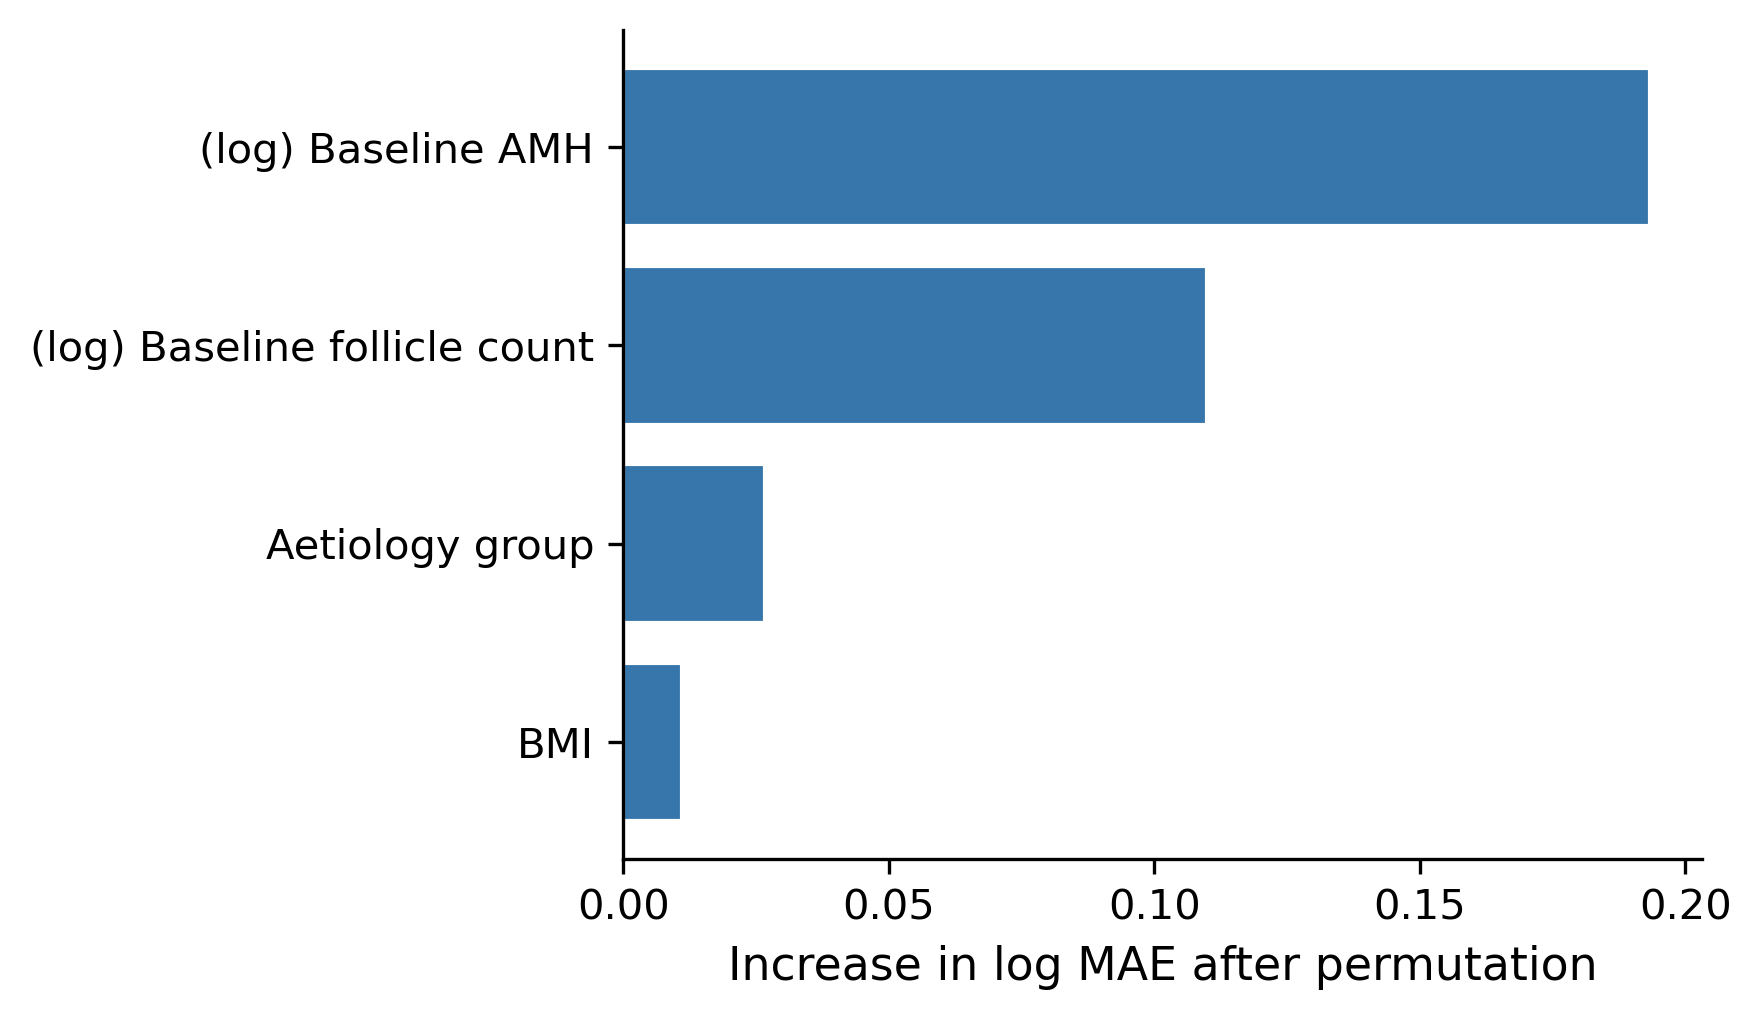

In [16]:
pretty_names = {
    "Baseline_AMH_log":       "(log) Baseline AMH",
    "Baseline_follicles_log": "(log) Baseline follicle count",
    "BMI_log":                "BMI (log)",
    "Aetiology_group":        "Aetiology group",
}
plot_df = importance_df.assign(
    label=importance_df["feature"].map(pretty_names).fillna(importance_df["feature"])
)

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)
ax.barh(plot_df["label"], plot_df["importance_mean"],
        #xerr=plot_df["importance_std"],
        color="#3776AB", edgecolor="white",
        error_kw=dict(ecolor="0.4", lw=1, capsize=3))
ax.invert_yaxis()
ax.set_xlabel("Increase in log MAE after permutation", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../figures/permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# SHAP fit once on full data
pipeline.fit(X, y)

X_processed = pipeline.named_steps["preprocessor"].transform(X)

ohe = (pipeline.named_steps["preprocessor"]
       .named_transformers_["cat"]
       .named_steps["onehot"])
cat_feature_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))

feature_names = NUMERIC_FEATURES + cat_feature_names
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

shap_pretty = {
    "Baseline_AMH_log":                 "(log) Baseline AMH",
    "Baseline_follicles_log":           "(log) Baseline follicle count",
    "BMI_log":                          "BMI",
    "Aetiology_group_No_female_factor": "No female factor",
    "Aetiology_group_Unexplained":      "Unexplained",
}
X_shap = X_processed_df.rename(columns=shap_pretty)

linear_svr = pipeline.named_steps["model"]

# Pass coefficients explicitly rather than relying on LinearExplainer
# introspecting SVR (works, but undocumented).
explainer = shap.LinearExplainer(
    (linear_svr.coef_[0], linear_svr.intercept_[0]),
    X_shap,
)
shap_values = explainer(X_shap)
shap_values.feature_names = list(X_shap.columns)


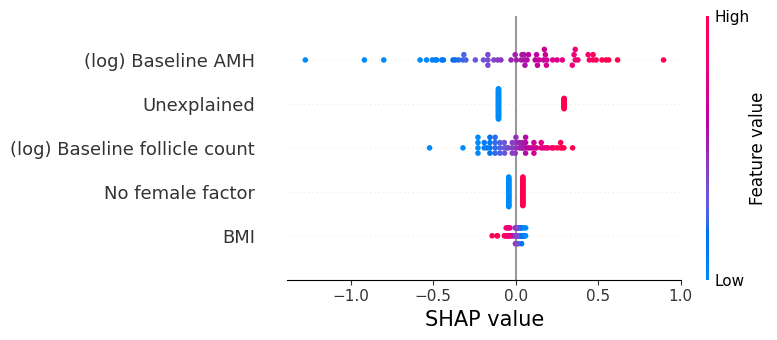

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shap.plots.beeswarm(shap_values, show=False)
plt.xlabel("SHAP value", fontsize=15)
plt.tight_layout()
plt.savefig("beeswarm.png", dpi=300, bbox_inches="tight")
plt.savefig("beeswarm.pdf", bbox_inches="tight")
plt.show()

from google.colab import files
files.download("beeswarm.png")